# BOOSTING ALGORITHMS TUTORIAL

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from matplotlib.colors import ListedColormap

sns.set_style("whitegrid")
sns.set_palette("colorblind")

plt.rcParams["figure.figsize"] = (10,6)

### Load Titanic Dataset

In [22]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Handle missing values

In [23]:
df = df[[
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]]

df["age"].fillna(df["age"].median(), inplace=True)

df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_277/1664659505.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/tmp/ipykernel_277/1664659505.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### Survival distribution plot

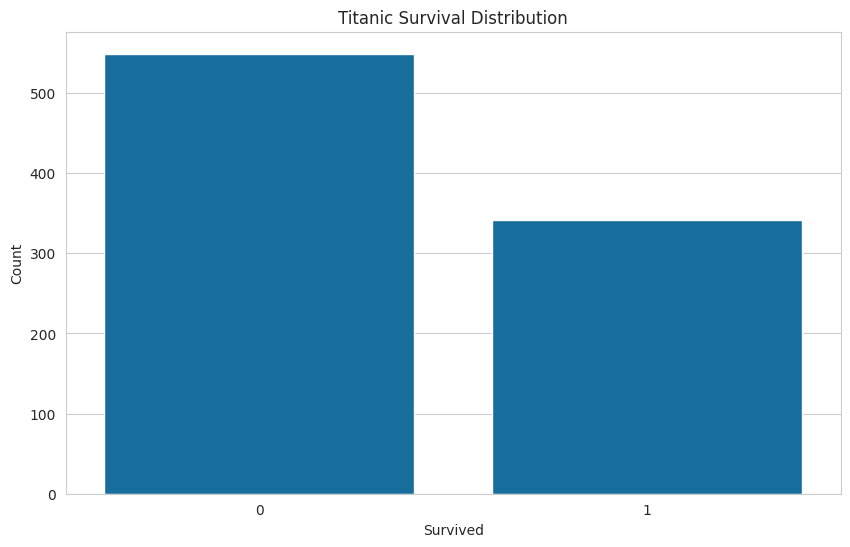

In [24]:
sns.countplot(x="survived", data=df)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.savefig("figure1_survival_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Define features & Target

In [25]:
X = df.drop("survived", axis=1)

y = df["survived"]

### Train - Test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train AdaBoost Model

In [27]:
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_preds = ada_model.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_preds)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.7988826815642458


### Train Gradient Boosting Model

In [28]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_preds)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8212290502793296


### Model Accuracy Comparison

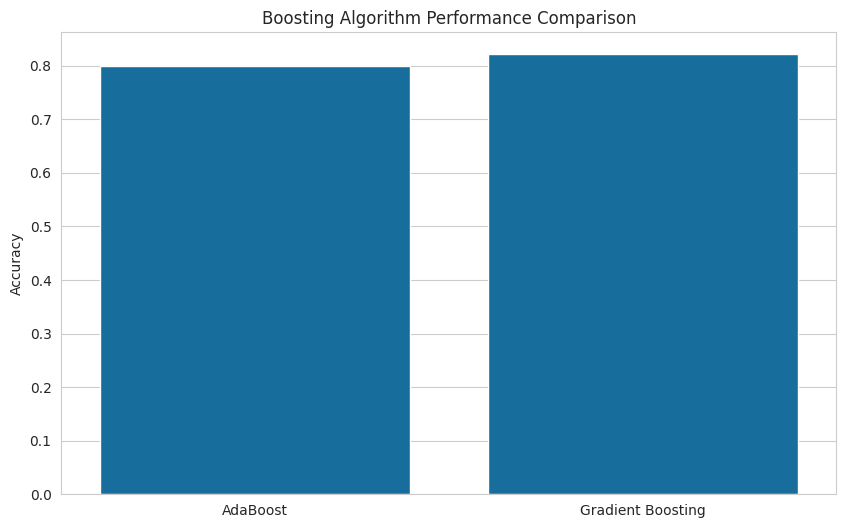

In [29]:
models = ["AdaBoost", "Gradient Boosting"]

scores = [ada_accuracy, gb_accuracy]

sns.barplot(x=models, y=scores)

plt.title("Boosting Algorithm Performance Comparison")
plt.ylabel("Accuracy")

plt.savefig("figure2_model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### AdaBoost Confusion Matrix

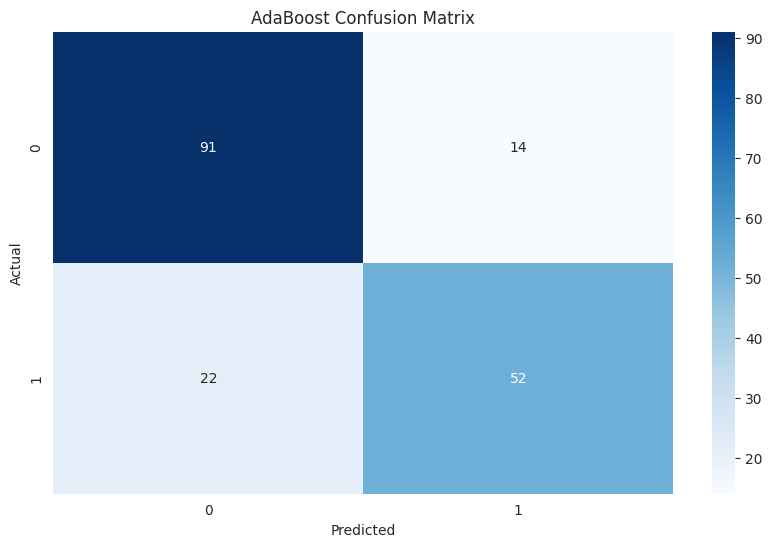

In [30]:
cm_ada = confusion_matrix(y_test, ada_preds)

sns.heatmap(
    cm_ada,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("figure3_adaboost_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Gradient Boosting Confusion Matrix

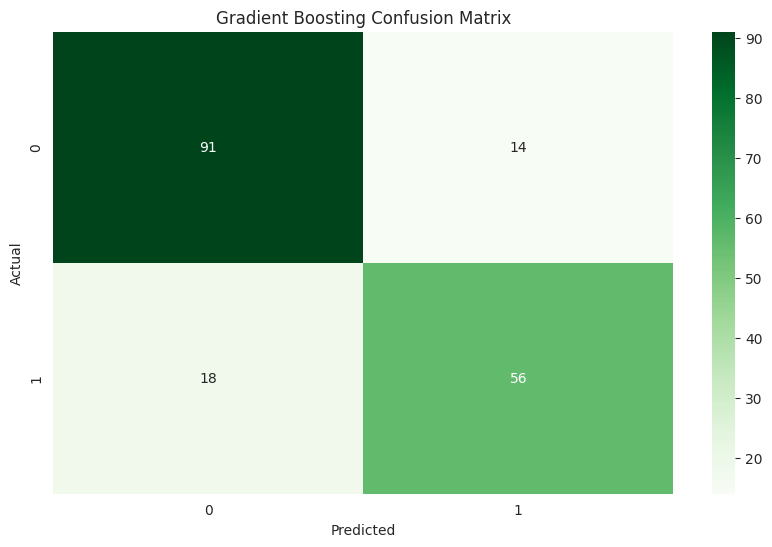

In [31]:
cm_gb = confusion_matrix(y_test, gb_preds)

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Gradient Boosting Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("figure4_gradient_boosting_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Boosting Learning Curve

In [32]:
estimator_range = [10, 50, 100, 150, 200]

ada_scores = []
gb_scores = []

for n in estimator_range:

    ada = AdaBoostClassifier(
        n_estimators=n,
        learning_rate=0.5,
        random_state=42
    )

    ada.fit(X_train, y_train)

    ada_pred = ada.predict(X_test)

    ada_scores.append(accuracy_score(y_test, ada_pred))


    gb = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )

    gb.fit(X_train, y_train)

    gb_pred = gb.predict(X_test)

    gb_scores.append(accuracy_score(y_test, gb_pred))

### Plot Boosting Learning Curve

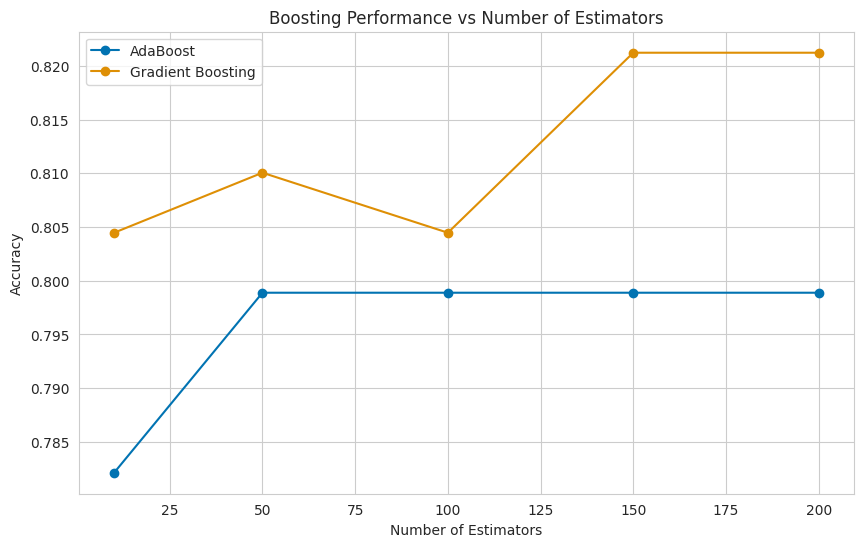

In [33]:
plt.plot(estimator_range, ada_scores, marker="o", label="AdaBoost")
plt.plot(estimator_range, gb_scores, marker="o", label="Gradient Boosting")

plt.title("Boosting Performance vs Number of Estimators")

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("figure5_boosting_learning_curve.png", dpi=300, bbox_inches="tight")

plt.show()

### Decision Boundary Visualisation Dataset

In [34]:
viz_df = df[["survived", "age", "fare"]].dropna()

X_viz = viz_df[["age", "fare"]]

y_viz = viz_df["survived"]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_viz,
    y_viz,
    test_size=0.2,
    random_state=42
)

### Train Boosting Models for Visualization

In [35]:
ada_viz = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

gb_viz = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

ada_viz.fit(X_train_v, y_train_v)
gb_viz.fit(X_train_v, y_train_v)

GradientBoostingClassifier(random_state=42)

In [36]:
def plot_decision_boundary(model, X, y, title, filename):

    x_min, x_max = X.iloc[:, 0].min() - 5, X.iloc[:, 0].max() + 5
    y_min, y_max = X.iloc[:, 1].min() - 10, X.iloc[:, 1].max() + 10

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 1),
        np.arange(y_min, y_max, 1)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])

    plt.contourf(xx, yy, Z, cmap=cmap_light)

    plt.scatter(
        X.iloc[:,0],
        X.iloc[:,1],
        c=y,
        edgecolor="k"
    )

    plt.xlabel("Age")
    plt.ylabel("Fare")

    plt.title(title)

    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

### Plot Decision Boundaries

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


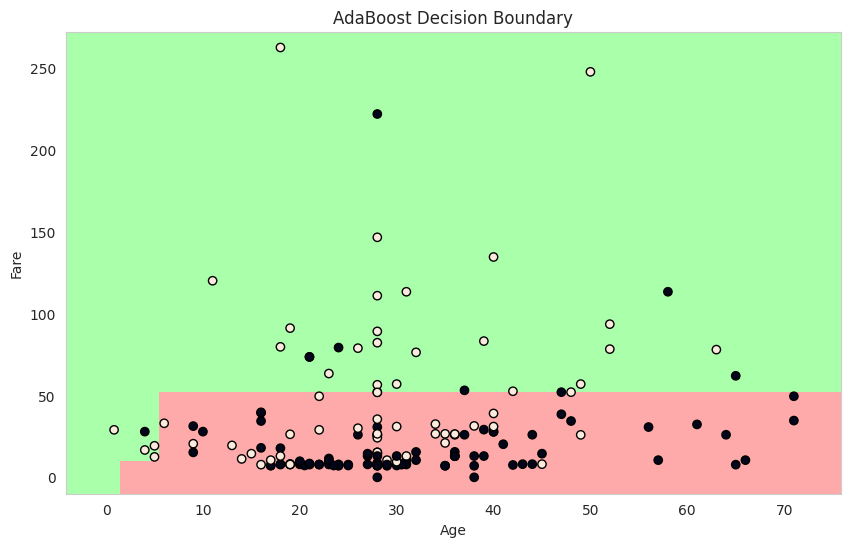

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


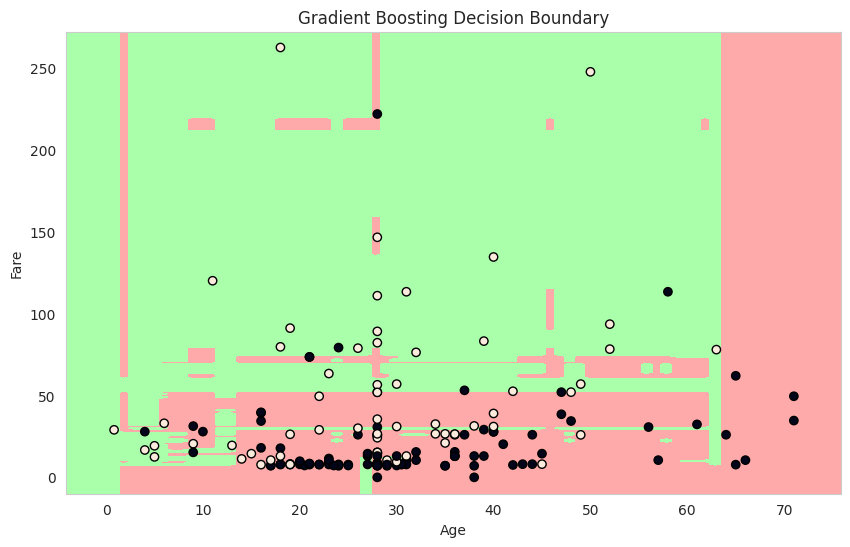

In [37]:
plot_decision_boundary(
    ada_viz,
    X_test_v,
    y_test_v,
    "AdaBoost Decision Boundary",
    "figure6_adaboost_boundary.png"
)

plot_decision_boundary(
    gb_viz,
    X_test_v,
    y_test_v,
    "Gradient Boosting Decision Boundary",
    "figure7_gradient_boosting_boundary.png"
)

### Classification reports

In [38]:
print("AdaBoost Report")
print(classification_report(y_test, ada_preds, zero_division=0))

print("\nGradient Boosting Report")
print(classification_report(y_test, gb_preds, zero_division=0))

AdaBoost Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Gradient Boosting Report
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

